In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, NullFormatter, ScalarFormatter
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn.objects as so
import sys
from matplotlib.offsetbox import AnchoredText


In [3]:

df = pd.read_csv("results/NeoN-GPU.csv", skip_blank_lines=True)
df = df.dropna(
    subset=["cells", "strategy", "julia_or_neon", "node", "time_us"]
).copy()
df["time_ms"] = df["time_us"] / 1000
df["ms_normed"] = df["time_ms"] / df["cells"]
df["us_normed"] = df["time_us"] / df["cells"]
df["mean_normed"] = df.groupby(["cells", "julia_or_neon", "strategy"])[
        "ms_normed"
].transform("median")
df["us_mean_normed"] = df.groupby(["cells", "julia_or_neon", "strategy"])[
        "us_normed"
].transform("median")
prefix = "gpustrats"
# df = df[df["strategy"] == "Cell-Based"]
cells = sorted(df[~df["cells"].isna()]["cells"].unique())
nnz_by_cells = (
    df.dropna(subset=["cells", "nnz"])[["cells", "nnz"]]
    .drop_duplicates("cells")
    .set_index("cells")["nnz"]
)
df["nnz"] = df["nnz"].fillna(df["cells"].map(nnz_by_cells))
print(df["nnz"].unique())
df["merged"] = df["strategy"] + df["julia_or_neon"]
df["merged"] = df["merged"].apply(lambda s: s.replace("JuNe", " (JuNe)").replace("NeoN", " (NeoN)"))
df["bandwidth"] = df["nnz"] * 24  / (df["time_ms"] * 1000000) 
print(df[(df["node"] == "gpu-nvidia-h200") & (df["julia_or_neon"] == "NeoN + Julia")]["cells"].unique())


[6.400000e+03 5.360000e+04 1.836000e+05 4.384000e+05 8.600000e+05
 1.490400e+06 2.371600e+06 3.545600e+06 5.054400e+06 6.940000e+06
 9.244400e+06 1.200960e+07 1.527760e+07 1.909040e+07 2.349000e+07
 2.851840e+07 3.421760e+07 4.062960e+07 4.779640e+07 5.576000e+07
 7.424560e+07 9.642240e+07 1.226264e+08 1.531936e+08 1.884600e+08
 2.287616e+08 2.744344e+08 3.258144e+08 3.832376e+08 4.470400e+08]
[]


In [4]:

def time_normed(_df, executor):
    sb.set_theme(rc={'figure.figsize':(10, 5)})
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    with sb.plotting_context("paper", font_scale=1.7):
        p = sb.lineplot(
            data=_df,
            x="cells",
            y="mean_normed",
            hue="merged",
            style="merged",
            markers=True,
            markersize=12,
            dashes=False
        )

        p.legend(title=executor)
        p.set(
            ylabel="Assembly Time per Cell [ms]",
            xlabel="#Cells",
            yscale="log",
            xscale="log",
        )
        plt.tight_layout()
        print(f"writing into {prefix}_{executor}_normed.svg")
    plt.savefig(f"{prefix}_{executor}_normed.svg")
    plt.clf()
    plt.cla()
    plt.close()


In [5]:


def time(_df, executor):
    sb.set_theme(rc={'figure.figsize':(10, 5)})
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    with sb.plotting_context("paper", font_scale=1.7):
        p = sb.lineplot(
            data=_df,
            x="cells",
            y="time_ms",
            hue="julia_or_neon",
            style="julia_or_neon",
            markers=True,
            markersize=12,
            dashes=False
        )

        p.legend(title=executor)
        p.set(
            ylabel="Assembly Time per Cell [ms]",
            xlabel="#Cells",
            yscale="log",
            xscale="log",
        )
        plt.tight_layout()
        print(f"writing into {prefix}_{executor}.svg")
    plt.savefig(f"{prefix}_{executor}.svg")
    plt.clf()
    plt.cla()
    plt.close()


In [6]:

def time_by_threads(_df, executor):
    group_cols = [
        "case",
        "strategy",
        "julia_or_neon",
    ]
    baseline = (
        _df[_df["threads"] == 1]
        .groupby(group_cols, as_index=False)["time_ms"]
        .first()
        .rename(columns={"time_ms": "serial_time"})
    )
    _df = _df.merge(baseline, on=group_cols, how="left")
    _df["speedup"] = _df["serial_time"] / _df["time_ms"]
    _df["efficiency"] = _df["speedup"] / _df["threads"]

    sb.set_theme(rc={'figure.figsize':(10, 5)})
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    ts = _df["threads"].unique()
    with sb.plotting_context("paper", font_scale=1.7):
        
        p = sb.lineplot(
            data=_df,
            x="threads",
            y="speedup",
            hue="julia_or_neon",
            style="julia_or_neon",
            markers=True,
            markersize=12,
            dashes=False
        )
        ax = p.axes
        # ax.plot([1, 128],[1,128], label="Ideal Speedup")
        p.legend(title=executor)
        p.set(
            ylabel="Speedup",
            xlabel="#Threads",
            xscale="log",
            xticks=ts,
            xticklabels=[str(t) for t in ts],
        )
        plt.tight_layout()
        print(f"writing into {prefix}_{executor}_speedup.svg")
        # handles, _ = ax.get_legend_handles_labels()
        # ax.legend_.remove()

        # ax.legend(
        #     handles,
        #     _df["julia_or_neon"].unique(),
        #     loc="upper left",
        #     title="Strategy"
        # )
    plt.savefig(f"{prefix}_{executor}_speedup.svg")
    plt.clf()
    plt.cla()
    plt.close()
executors = df["executor"].unique()
print(f"executors : {executors}")


executors : <StringArray>
['GPU']
Length: 1, dtype: str


In [7]:

# def strategies(_df, executor):
#     sb.set_theme(rc={'figure.figsize':(10, 5)})
#     sb.set_style("whitegrid")
#     sb.color_palette("deep", 8)
#     nodes = _df["node"].unique()
#     with sb.plotting_context("paper", font_scale=1.7):
#         fig, axes = plt.subplots(1, len(nodes))
#         for ax, node in zip(axes, nodes):
#             p = sb.lineplot(
#                 data=_df[_df["node"] == node],
#                 x="cells",
#                 y="ms_normed",
#                 hue="merged",
#                 err_style=None,
#                 style="merged",
#                 markers=True,
#                 markersize=12,
#                 dashes=False,
#                 ax=ax,
#             )

#             p.legend(title=node)
#             p.set(
#                 ylabel="Assembly Time per Cell [ms]",
#                 xlabel="#Cells",
#                 yscale="log",
#                 xscale="log",
#             )
#         handles, labels = axes[0].get_legend_handles_labels()
#         leg = axes[0].get_legend()
#         if leg is not None:
#             leg.remove()
#         fig.legend(
#             handles,
#             labels,
#             loc="center right",
#             bbox_to_anchor=(1, 0.5),
#             ncol=1,
#             # title="Fused Strategy",
#             frameon=False,
#         )
#         fig.subplots_adjust(
#             left=0.05,
#             right=0.99,
#             # bottom=0.18,
#             # top=0.78,
#             wspace=0.25,
#         )
#         print(f"writing into {prefix}_{executor}_all.svg")
#     plt.savefig(f"{prefix}_{executor}_all.svg")
#     plt.clf()
#     plt.cla()
#     plt.close()

    

# for executor in executors:
#     if "CPU-Parallel" == executor:
#         time_by_threads(df[(df["executor"] == executor)], executor)
#     time_normed(df[df["executor"] == executor], executor)
#     time(df[df["executor"] == executor], executor)
# time(df[df["executor"] == "GPU"], "GPU")
# strategies(df, "GPU")
# df.to_csv("interface_strats.csv")


<StringArray>
['gpu-nvidia-h100', 'gpu-nvidia-h200']
Length: 2, dtype: str


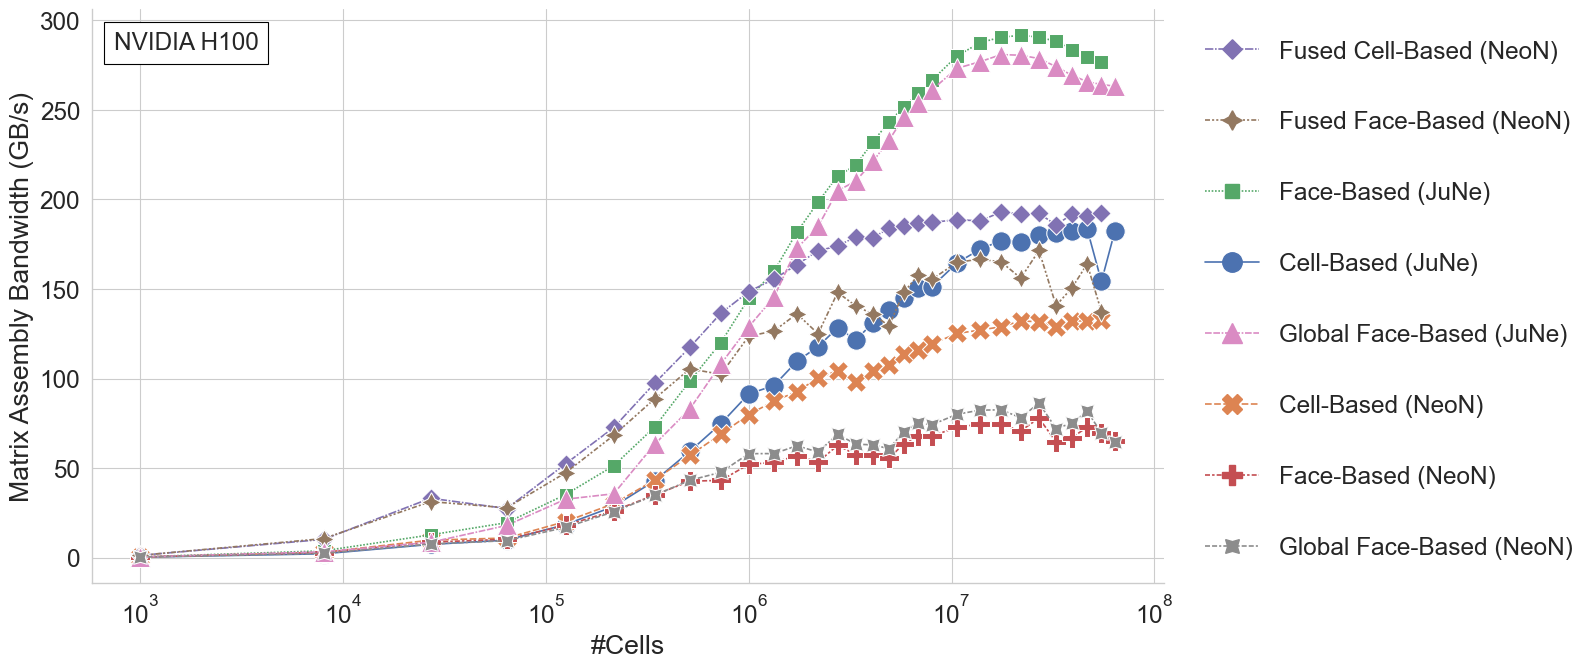

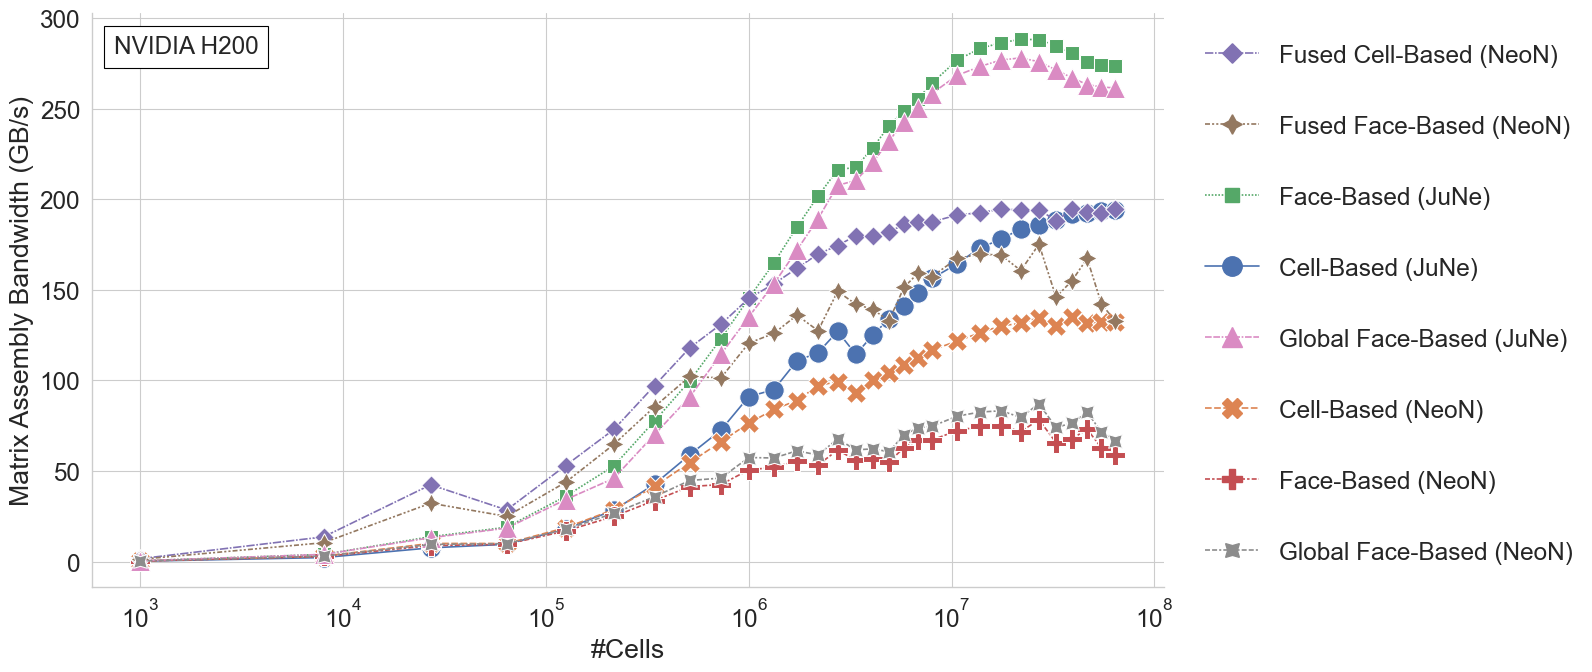

In [8]:
# GPU interface bandwidth, styled like cpu-bandwidth-difference-amd-intel-128
sb.set_style("whitegrid")
gpu_bandwidth_figure_size = (16, 7)
gpu_bandwidth_plot_bounds = {
    "left": 0.06,
    "right": 0.73,
    "bottom": 0.14,
    "top": 0.96,
}
gpu_bandwidth_legend_x = 0.75
gpu_bandwidth_legend_y_limits = (0.90, 0.19)
gpu_bandwidth_strategy_order = sorted(df["merged"].dropna().unique())
gpu_bandwidth_palette = dict(
    zip(
        gpu_bandwidth_strategy_order,
        sb.color_palette("deep", n_colors=len(gpu_bandwidth_strategy_order)),
    )
)
# Match the CPU bandwidth plots: order by the final AMD values.
gpu_legend_order = [
    "Fused Cell-Based (NeoN)",
    "Fused Face-Based (NeoN)",
    "Face-Based (JuNe)",
    "Cell-Based (JuNe)",
    "Global Face-Based (JuNe)",
    "Cell-Based (NeoN)",
    "Face-Based (NeoN)",
    "Global Face-Based (NeoN)",
]

nodes = df["node"].dropna().unique()
print(nodes)
for node in nodes:
    with sb.plotting_context("paper", font_scale=2):
        plot_df = df[df["node"] == node].copy()
        p = sb.relplot(
            data=plot_df,
            x="cells",
            y="bandwidth",
            kind="line",
            hue="merged",
            style="merged",
            hue_order=gpu_bandwidth_strategy_order,
            style_order=gpu_bandwidth_strategy_order,
            palette=gpu_bandwidth_palette,
            err_style=None,
            markers=True,
            markersize=14,
            height=gpu_bandwidth_figure_size[1],
            aspect=(
                gpu_bandwidth_figure_size[0]
                / gpu_bandwidth_figure_size[1]
            ),
        )
        p.fig.set_size_inches(*gpu_bandwidth_figure_size, forward=True)
        p.set(
            xscale="log",
            xlabel="#Cells",
            ylabel="Matrix Assembly Bandwidth (GB/s)",
        )

        handles, labels = p.axes.flat[0].get_legend_handles_labels()
        if p._legend is not None:
            p._legend.remove()
            p._legend = None
        by_label = dict(zip(labels, handles))
        ordered_labels = [
            label for label in gpu_legend_order if label in by_label
        ]
        ordered_handles = [by_label[label] for label in ordered_labels]

        node_label = "NVIDIA H100" if "h100" in node else "NVIDIA H200"
        p.axes.flat[0].add_artist(
            AnchoredText(
                node_label,
                loc="upper left",
                bbox_transform=p.axes.flat[0].transAxes,
                frameon=True,
                prop={"size": plt.rcParams["legend.fontsize"]},
            )
        )
        p.set_titles("")

        legend_y_positions = np.linspace(
            *gpu_bandwidth_legend_y_limits,
            len(ordered_labels),
        )
        for handle, label, legend_y in zip(
            ordered_handles,
            ordered_labels,
            legend_y_positions,
        ):
            p.fig.legend(
                [handle],
                [label],
                loc="center left",
                bbox_to_anchor=(gpu_bandwidth_legend_x, float(legend_y)),
                handlelength=2.2,
                borderaxespad=0,
                frameon=False,
            )
        p.fig.subplots_adjust(**gpu_bandwidth_plot_bounds)
        p.fig.savefig(f"gpu_interface_strategies_{node}.svg")


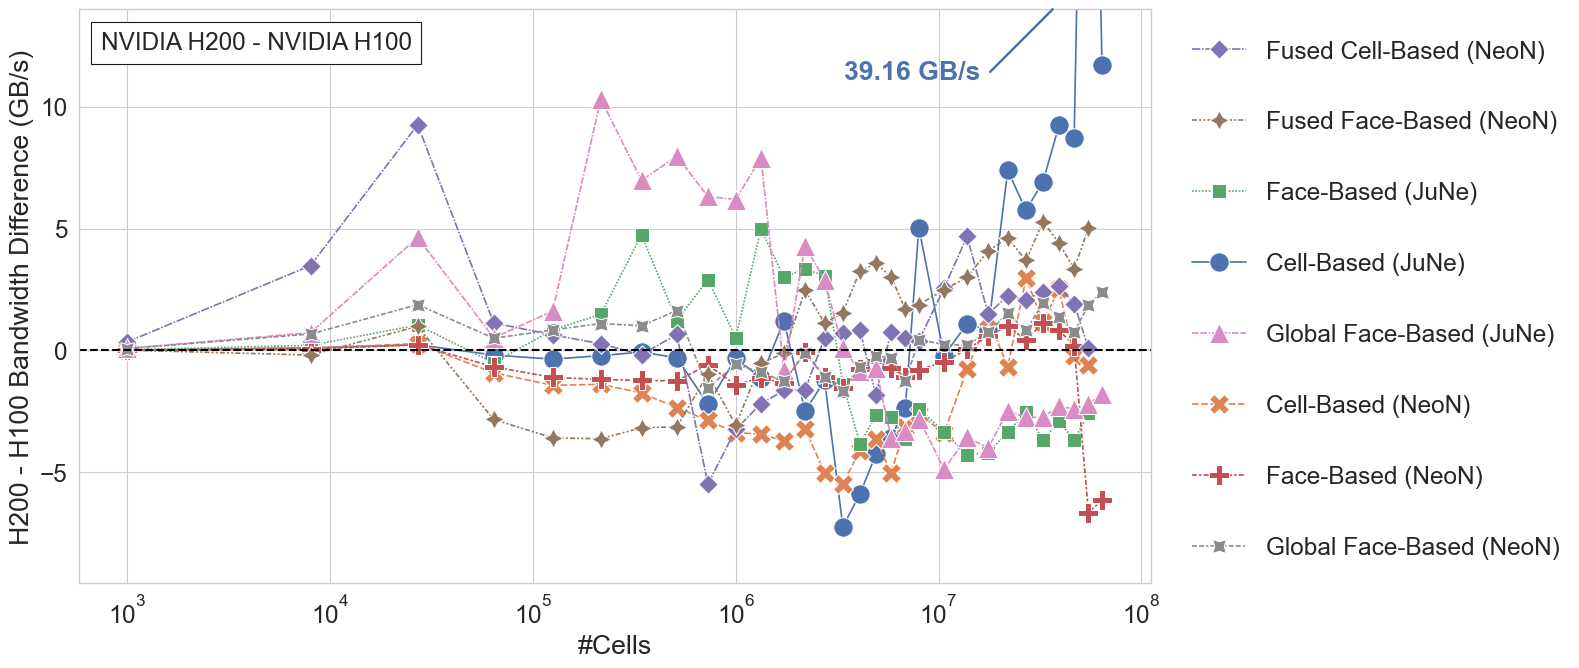

In [20]:
# NVIDIA H200 - NVIDIA H100 bandwidth difference
gpu_mean_bandwidth = df.groupby(
    ["node", "merged", "cells"], as_index=False
)["bandwidth"].mean()
gpu_h200_bandwidth = (
    gpu_mean_bandwidth[gpu_mean_bandwidth["node"] == "gpu-nvidia-h200"]
    .drop(columns="node")
    .rename(columns={"bandwidth": "bandwidth_h200"})
)
gpu_h100_bandwidth = (
    gpu_mean_bandwidth[gpu_mean_bandwidth["node"] == "gpu-nvidia-h100"]
    .drop(columns="node")
    .rename(columns={"bandwidth": "bandwidth_h100"})
)
gpu_bandwidth_difference_df = gpu_h200_bandwidth.merge(
    gpu_h100_bandwidth, on=["merged", "cells"], how="inner"
)
gpu_bandwidth_difference_df["bandwidth_difference"] = (
    gpu_bandwidth_difference_df["bandwidth_h200"]
    - gpu_bandwidth_difference_df["bandwidth_h100"]
)
gpu_difference_available_strategies = set(
    gpu_bandwidth_difference_df["merged"].unique()
)
gpu_difference_strategy_order = [
    strategy for strategy in gpu_bandwidth_strategy_order
    if strategy in gpu_difference_available_strategies
]

with sb.plotting_context("paper", font_scale=2):
    gpu_difference_fig, gpu_difference_ax = plt.subplots(
        figsize=gpu_bandwidth_figure_size
    )
    sb.lineplot(
        data=gpu_bandwidth_difference_df,
        x="cells", y="bandwidth_difference",
        hue="merged", style="merged",
        hue_order=gpu_difference_strategy_order,
        style_order=gpu_difference_strategy_order,
        palette=gpu_bandwidth_palette,
        err_style=None, markers=True, markersize=14,
        ax=gpu_difference_ax,
    )
    gpu_difference_ax.set(
        xscale="log", xlabel="#Cells",
        ylabel="H200 - H100 Bandwidth Difference (GB/s)",
    )
    gpu_difference_ax.axhline(
        0, color="black", linestyle="--", linewidth=1.5
    )

    # Keep the useful scale while marking the clipped Cell-Based (JuNe) outlier.
    gpu_ghost_candidates = gpu_bandwidth_difference_df[
        gpu_bandwidth_difference_df["merged"] == "Cell-Based (JuNe)"
    ]
    gpu_ghost_index = gpu_ghost_candidates["bandwidth_difference"].idxmax()
    gpu_ghost_row = gpu_bandwidth_difference_df.loc[gpu_ghost_index]
    gpu_visible_max = gpu_bandwidth_difference_df.drop(
        index=gpu_ghost_index
    )["bandwidth_difference"].max()
    gpu_ghost_ymax = np.ceil(gpu_visible_max * 1.15)
    gpu_ghost_ymin = gpu_difference_ax.get_ylim()[0]
    gpu_difference_ax.set_ylim(gpu_ghost_ymin, gpu_ghost_ymax)
    gpu_ghost_color = gpu_bandwidth_palette[gpu_ghost_row["merged"]]
    gpu_ghost_indicator_x = gpu_ghost_row["cells"] / 1.5
    gpu_difference_ax.annotate(
        "",
        xy=(gpu_ghost_indicator_x, gpu_ghost_ymax),
        xytext=(-45, -45),
        textcoords="offset points",
        annotation_clip=False,
        arrowprops={
            "arrowstyle": "-", "color": gpu_ghost_color,
            "linewidth": 1.8, "shrinkA": 0, "shrinkB": 0,
        },
    )
    gpu_difference_ax.annotate(
        f"{gpu_ghost_row['bandwidth_difference']:.2f} GB/s",
        xy=(gpu_ghost_indicator_x, gpu_ghost_ymax),
        xytext=(-52, -45),
        textcoords="offset points",
        ha="right", va="center", color=gpu_ghost_color,
        fontweight="bold", annotation_clip=False,
    )
    gpu_difference_handles, gpu_difference_labels = (
        gpu_difference_ax.get_legend_handles_labels()
    )
    gpu_difference_legend = gpu_difference_ax.get_legend()
    if gpu_difference_legend is not None:
        gpu_difference_legend.remove()
    gpu_difference_by_label = dict(
        zip(gpu_difference_labels, gpu_difference_handles)
    )
    gpu_difference_ordered_labels = [
        label for label in gpu_legend_order
        if label in gpu_difference_by_label
    ]
    gpu_difference_ordered_handles = [
        gpu_difference_by_label[label]
        for label in gpu_difference_ordered_labels
    ]
    gpu_difference_ax.add_artist(
        AnchoredText(
            "NVIDIA H200 - NVIDIA H100", loc="upper left",
            bbox_transform=gpu_difference_ax.transAxes, frameon=True,
            prop={"size": plt.rcParams["legend.fontsize"]},
        )
    )
    gpu_difference_legend_y_positions = np.linspace(
        *gpu_bandwidth_legend_y_limits,
        len(gpu_difference_ordered_labels),
    )
    for handle, label, legend_y in zip(
        gpu_difference_ordered_handles,
        gpu_difference_ordered_labels,
        gpu_difference_legend_y_positions,
    ):
        gpu_difference_fig.legend(
            [handle], [label], loc="center left",
            bbox_to_anchor=(gpu_bandwidth_legend_x, float(legend_y)),
            handlelength=2.2, borderaxespad=0, frameon=False,
        )
    gpu_difference_fig.subplots_adjust(**gpu_bandwidth_plot_bounds)
    gpu_difference_fig.savefig(
        "gpu_interface_strategies_difference-h200-h100.svg"
    )


<StringArray>
['gpu-nvidia-h100', 'gpu-nvidia-h200']
Length: 2, dtype: str
labels: ['Fused Face-Based (NeoN)', 'Cell-Based (NeoN)', 'Face-Based (NeoN)', 'Face-Based (JuNe)', 'Cell-Based (JuNe)', 'Fused Cell-Based (NeoN)', 'Global Face-Based (NeoN)', 'Global Face-Based (JuNe)']


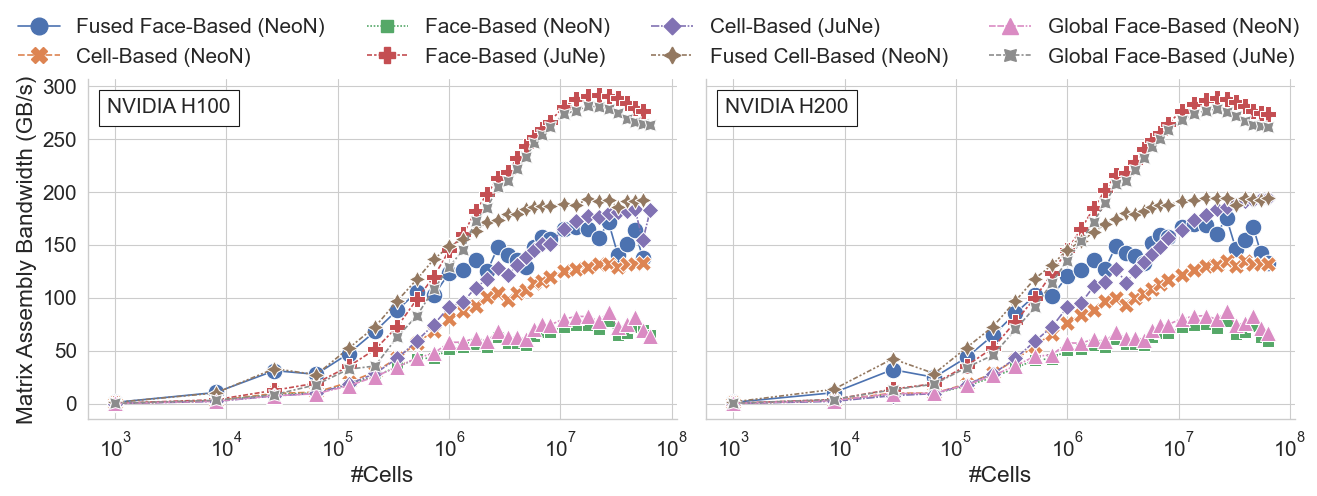

In [9]:

sb.set_theme(rc={'figure.figsize':(20, 12)})
sb.set_style("whitegrid")
sb.color_palette("deep", 8)
nodes = df["node"].unique()
print(df["node"].unique())
with sb.plotting_context("paper", font_scale=1.7):
    # plot_df = df[df["node"] == node].copy()
    p = sb.relplot(
        data=df,
        x="cells",
        y="bandwidth",
        style="merged",
        col="node",
        col_order=["gpu-nvidia-h100", "gpu-nvidia-h200"],
        err_style=None,
        hue="merged",
        kind="line",
        markers=True,
        markersize=12
    )
    p.set(
        # yscale="log",
        xscale="log",
        xlabel="#Cells",
        ylabel="Matrix Assembly Bandwidth (GB/s)"
    )
    legend_heights = plot_df.groupby(["merged", "cells"], as_index=False)["bandwidth"].mean()
    rightmost_points = legend_heights.loc[legend_heights.groupby("merged")["cells"].idxmax()]
    legend_order = rightmost_points.sort_values("bandwidth", ascending=False)["merged"].tolist()

    handles, labels = p.axes.flat[0].get_legend_handles_labels()
    if p._legend is not None:
        p._legend.remove()
        p._legend = None
    print(f"labels: {labels}")
    by_label = dict(zip(labels, handles))

    ordered_labels = [label for label in legend_order if label in by_label]
    ordered_handles = [by_label[label] for label in ordered_labels]
    at = AnchoredText(
        "NVIDIA H100",
        loc="upper left",
        # bbox_to_anchor=(0.975, 0.92),
        bbox_transform=p.axes.flat[0].transAxes,
        frameon=True,
        prop={"size": plt.rcParams["legend.fontsize"]},
    )
    p.axes.flat[0].add_artist(at)  
    at = AnchoredText(
        "NVIDIA H200",
        loc="upper left",
        # bbox_to_anchor=(0.975, 0.92),
        bbox_transform=p.axes.flat[1].transAxes,
        frameon=True,
        prop={"size": plt.rcParams["legend.fontsize"]},
    )
    p.axes.flat[1].add_artist(at)    
    p.set_titles("")
    handles, labels = p.axes.flat[0].get_legend_handles_labels()
    for ax in p.axes.flat:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    # # One shared legend above all subplots, 4 columns
    p.fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=4,
        # title="Fused Strategy",
        frameon=False,
    )
    # plt.tight_layout()
    p.fig.subplots_adjust(
        left=0.07,
        right=0.98,
        # bottom=0.18,
        top=0.84,
        wspace=0.05,
    )
    plt.savefig(f"gpu_interface_strategies_both.svg", bbox_inches='tight')



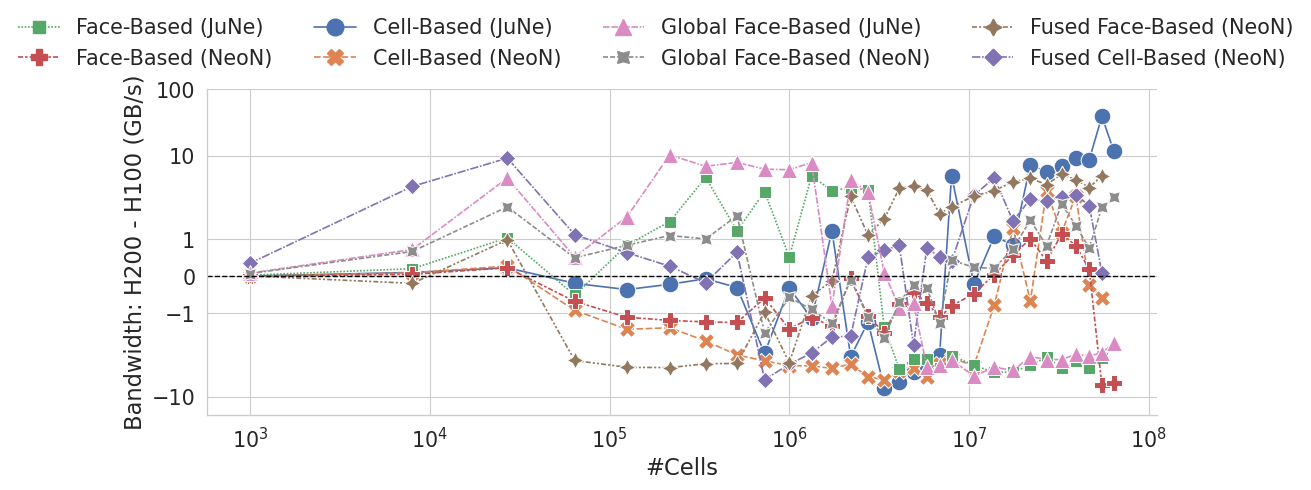

In [10]:
sb.set_theme(rc={'figure.figsize':(20, 12)})
sb.set_style("whitegrid")
sb.color_palette("deep", 8)

diff_df = (
    df[df["node"].isin(["gpu-nvidia-h100", "gpu-nvidia-h200"])]
    .pivot_table(
        index=["cells", "merged"],
        columns="node",
        values="bandwidth",
        aggfunc="mean",
    )
    .dropna(subset=["gpu-nvidia-h100", "gpu-nvidia-h200"])
    .reset_index()
)
diff_df["bandwidth_difference"] = diff_df["gpu-nvidia-h200"] - diff_df["gpu-nvidia-h100"]

with sb.plotting_context("paper", font_scale=1.7):
    p = sb.relplot(
        data=diff_df,
        x="cells",
        y="bandwidth_difference",
        style="merged",
        hue="merged",
        kind="line",
        markers=True,
        markersize=12,
        err_style=None,
        aspect=1.4
    )
    p.set(
        xscale="log",
        xlabel="#Cells",
        yscale="symlog",
        ylabel="Bandwidth: H200 - H100 (GB/s)",
    )

    ax = p.axes.flat[0]
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.margins(y=0.1)
    ax.axhline(0, color="black", linewidth=1, linestyle="--")

    legend_order = [
        "Face-Based (JuNe)",
        "Face-Based (NeoN)",
        "Cell-Based (JuNe)",
        "Cell-Based (NeoN)",
        "Global Face-Based (JuNe)",
        "Global Face-Based (NeoN)",
        "Fused Face-Based (NeoN)",
        "Fused Cell-Based (NeoN)",
    ]

    handles, labels = ax.get_legend_handles_labels()
    if p._legend is not None:
        p._legend.remove()
        p._legend = None

    by_label = dict(zip(labels, handles))
    ordered_labels = [label for label in legend_order if label in by_label]
    ordered_handles = [by_label[label] for label in ordered_labels]

    p.fig.legend(
        ordered_handles,
        ordered_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=4,
        frameon=False,
    )
    p.fig.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.82,
    )
    plt.savefig("gpu_interface_strategies_h200_minus_h100.svg", bbox_inches="tight")


KeyError: "['gpu_time_ms'] not in index"

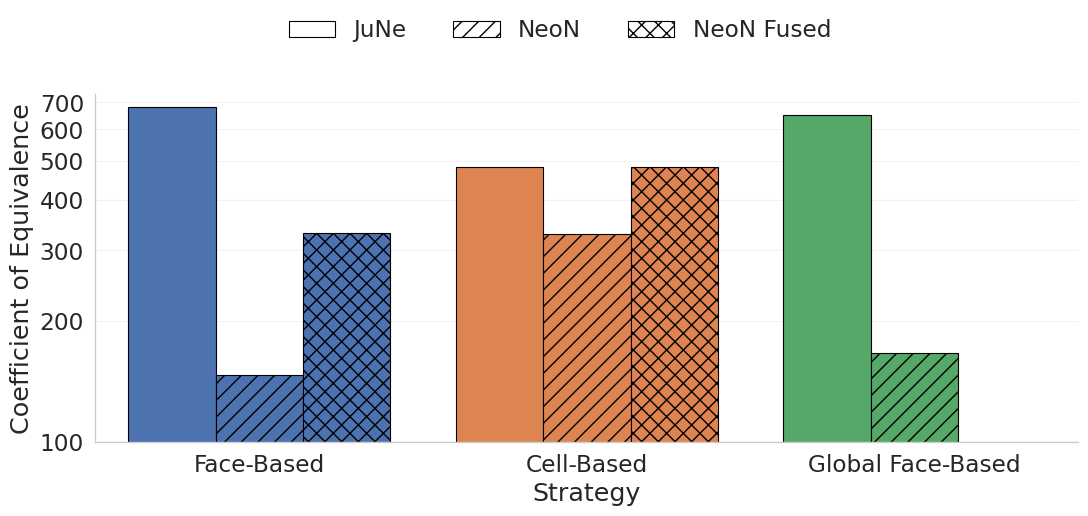

In [16]:
cpu_coe = pd.read_csv("results/icoFoam-mpi.csv", skip_blank_lines=True).dropna(how="all")
gpu_coe = pd.read_csv("results/NeoN-GPU.csv", skip_blank_lines=True).dropna(how="all")

cpu_coe = cpu_coe[cpu_coe["cell_dim"] == 400].copy()
cpu_coe["nprocs"] = pd.to_numeric(cpu_coe["nprocs"], errors="raise").astype(int)
cpu_coe["cpu_time_s"] = pd.to_numeric(cpu_coe["time_s"], errors="raise")
cpu_coe = cpu_coe[cpu_coe["nprocs"] == 64]

gpu_coe = gpu_coe[
    (gpu_coe["case"] == "LDC_N400")
    & (gpu_coe["executor"].str.upper() == "GPU")
    & (gpu_coe["node"] == "gpu-nvidia-h200")
].copy()
gpu_coe["cells"] = pd.to_numeric(gpu_coe["cells"], errors="raise").astype(int)
gpu_coe["time_s"] = pd.to_numeric(gpu_coe["time_us"], errors="raise") / 1_000_000
gpu_coe["nnz"] = pd.to_numeric(gpu_coe["nnz"], errors="coerce")
ldc_400_nnz = gpu_coe["nnz"].dropna().iloc[0]
gpu_coe["nnz"] = gpu_coe["nnz"].fillna(ldc_400_nnz)
gpu_coe["merged"] = gpu_coe["strategy"] + " (" + gpu_coe["julia_or_neon"] + ")"
gpu_coe["plot_strategy"] = gpu_coe["strategy"].str.replace("Fused ", "", regex=False)
gpu_coe["runtime"] = gpu_coe["julia_or_neon"]
gpu_coe.loc[gpu_coe["strategy"].str.startswith("Fused"), "runtime"] = "NeoN Fused"

gpu_mean = (
    gpu_coe.groupby(["node", "strategy", "plot_strategy", "julia_or_neon", "runtime", "merged"], as_index=False)
    .agg(
        cells=("cells", "first"),
        nnz=("nnz", "first"),
        gpu_time_s=("time_s", "mean"),
    )
)
gpu_mean["fvops_gpu"] = gpu_mean["nnz"] / gpu_mean["gpu_time_s"]

coe_400 = cpu_coe.merge(gpu_mean, how="cross")
coe_400["fvops_cpu"] = coe_400["nnz"] / coe_400["cpu_time_s"]
coe_400["coe"] = coe_400["fvops_gpu"] / (coe_400["fvops_cpu"] / coe_400["nprocs"])
coe_400 = coe_400.sort_values(["node", "merged", "nprocs"]).reset_index(drop=True)
coe_400.to_csv("results/coe_icofoam_mpi_neon_gpu_ldc400.csv", index=False)

strategy_order = [
    "Face-Based",
    "Cell-Based",
    "Global Face-Based",
]
strategy_order = [label for label in strategy_order if label in set(coe_400["plot_strategy"])]
strategy_palette = dict(zip(strategy_order, sb.color_palette("deep", len(strategy_order))))
runtime_order = ["JuNe", "NeoN", "NeoN Fused"]
runtime_order = [label for label in runtime_order if label in set(coe_400["runtime"])]
runtime_hatches = {"JuNe": "", "NeoN": "//", "NeoN Fused": "xx"}

sb.set_theme(rc={'figure.figsize':(20, 12)})
sb.set_style("whitegrid")
with sb.plotting_context("paper", font_scale=1.9):
    p = sb.catplot(
        data=coe_400,
        x="plot_strategy",
        y="coe",
        hue="runtime",
        order=strategy_order,
        hue_order=runtime_order,
        palette={runtime: "lightgray" for runtime in runtime_order},
        kind="bar",
        errorbar=None,
        height=6,
        aspect=1.8,
        legend=False,
    )
    ax = p.axes.flat[0]
    for container, runtime in zip(ax.containers, runtime_order):
        for bar, strategy in zip(container, strategy_order):
            bar.set_facecolor(strategy_palette[strategy])
            bar.set_hatch(runtime_hatches[runtime])
            bar.set_edgecolor("black")
            bar.set_linewidth(0.8)
    p.set(
        yscale="log",
        xlabel="Strategy",
        ylabel="Coefficient of Equivalence",
    )
    p.set_titles("")

    for ax in p.axes.flat:
        ax.set_xticks(range(len(strategy_order)))
        ax.set_xticklabels(strategy_order, rotation=0, ha="center")
        ax.set_yticks(range(100, int(coe_400["coe"].max() // 100 + 2) * 100, 100))
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_minor_formatter(NullFormatter())
        ax.grid(True, axis="y", which="both", alpha=0.25)
        # ax.add_artist(AnchoredText(
        #     "NVIDIA H200, 64 CPU processes",
        #     loc="upper center",
        #     bbox_transform=ax.transAxes,
        #     frameon=True,
        #     prop={"size": plt.rcParams["legend.fontsize"]},
        # ))

    runtime_handles = [
        Patch(facecolor="white", edgecolor="black", hatch=runtime_hatches[label], label=label)
        for label in runtime_order
    ]
    p.fig.legend(
        runtime_handles,
        [handle.get_label() for handle in runtime_handles],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=3,
        title="",
        frameon=False,
    )
    p.fig.subplots_adjust(
        left=0.07,
        right=0.98,
        bottom=0.26,
        top=0.84,
    )
    plt.savefig("coe-ldc400-64-h200.svg", bbox_inches="tight")

coe_400[["node", "merged", "nprocs", "fvops_gpu", "fvops_cpu", "coe", "gpu_time_ms"]]


In [18]:
coe_400["gpu_time_ms"] = coe_400["gpu_time_s"] * 1000
coe_400[["node", "merged", "nprocs", "fvops_gpu", "fvops_cpu", "coe", "gpu_time_ms"]]


,node,merged,nprocs,fvops_gpu,fvops_cpu,coe,gpu_time_ms
0,gpu-nvidia-h200,Cell-Based (JuNe),64,8.096008e+09,1.073292e+09,482.762031,55.217333
1,gpu-nvidia-h200,Cell-Based (NeoN),64,5.502053e+09,1.073292e+09,328.085432,81.249667
2,gpu-nvidia-h200,Face-Based (JuNe),64,1.139536e+10,1.073292e+09,679.501198,39.230000
3,gpu-nvidia-h200,Face-Based (NeoN),64,2.459295e+09,1.073292e+09,146.646867,181.775667
4,gpu-nvidia-h200,Fused Cell-Based (NeoN),64,8.101241e+09,1.073292e+09,483.074064,55.181667
5,gpu-nvidia-h200,Fused Face-Based (NeoN),64,5.536099e+09,1.073292e+09,330.115567,80.750000
6,gpu-nvidia-h200,Global Face-Based (JuNe),64,1.089296e+10,1.073292e+09,649.543495,41.039333
7,gpu-nvidia-h200,Global Face-Based (NeoN),64,2.782828e+09,1.073292e+09,165.939024,160.642333


In [ ]:
# #let drivaer-performance-table = figure(
#   table(
#     columns: (1fr, 1.3fr, 1.2fr, 1fr, 0.5fr, 0.8fr),
#     align: (center, center, center, center, center, center),
#     table.header(
#       [Impl.],
#       [Strategy],
#       [Assembly time #linebreak() (ms)],
#       [Bandwidth #linebreak() (GB/s)],
#       [Speedup],
#       [COE],
#     ),
#      [JuNe], [Cell-Based],  [55.22], [194.30], [1.47x], [482.7],
#      [], [Face-Based],  best[39.23], best[273.49], best[4.63x], best[679.5],
#      [], [Global Face-Based],  [41.04], [261.43], [3.91x], [649.5],
#      [NeoN, fused], [Fused Face-Based],  [80.75], [132.87], [2.25x], [330.1],
#      [], [Fused Cell-Based],  [55.18], [194.43], [1.47x], [483.0],
#      [NeoN], [Cell-Based],  [81.25], [132.05], [1.00x], [328.0],
#      [], [Face-Based],  [181.78], [59.02], [1.00x], [146.6],
#      [], [Global Face-Based],  [160.64], [66.79], [1.00x], [165.9],
#   ),
#   caption: [
#     DrivAer GPU benchmark on the H200 GPU. Speedup is calculated with respect to the corresponding non-fused NeoN strategy.
#   ],
# )

,cell_dim,time_s,nprocs,cpu_time_s,node,strategy,plot_strategy,julia_or_neon,runtime,merged,cells,nnz,gpu_time_s,fvops_gpu,fvops_cpu,coe,gpu_time_ms
0,400,0.416513,64,0.416513,gpu-nvidia-h200,Cell-Based,Cell-Based,JuNe,JuNe,Cell-Based (JuNe),64000000,447040000.0,0.055217,8.096008e+09,1.073292e+09,482.762031,55.217333
1,400,0.416513,64,0.416513,gpu-nvidia-h200,Cell-Based,Cell-Based,NeoN,NeoN,Cell-Based (NeoN),64000000,447040000.0,0.081250,5.502053e+09,1.073292e+09,328.085432,81.249667
2,400,0.416513,64,0.416513,gpu-nvidia-h200,Face-Based,Face-Based,JuNe,JuNe,Face-Based (JuNe),64000000,447040000.0,0.039230,1.139536e+10,1.073292e+09,679.501198,39.230000
3,400,0.416513,64,0.416513,gpu-nvidia-h200,Face-Based,Face-Based,NeoN,NeoN,Face-Based (NeoN),64000000,447040000.0,0.181776,2.459295e+09,1.073292e+09,146.646867,181.775667
4,400,0.416513,64,0.416513,gpu-nvidia-h200,Fused Cell-Based,Cell-Based,NeoN,NeoN Fused,Fused Cell-Based (NeoN),64000000,447040000.0,0.055182,8.101241e+09,1.073292e+09,483.074064,55.181667
5,400,0.416513,64,0.416513,gpu-nvidia-h200,Fused Face-Based,Face-Based,NeoN,NeoN Fused,Fused Face-Based (NeoN),64000000,447040000.0,0.080750,5.536099e+09,1.073292e+09,330.115567,80.750000
6,400,0.416513,64,0.416513,gpu-nvidia-h200,Global Face-Based,Global Face-Based,JuNe,JuNe,Global Face-Based (JuNe),64000000,447040000.0,0.041039,1.089296e+10,1.073292e+09,649.543495,41.039333
7,400,0.416513,64,0.416513,gpu-nvidia-h200,Global Face-Based,Global Face-Based,NeoN,NeoN,Global Face-Based (NeoN),64000000,447040000.0,0.160642,2.782828e+09,1.073292e+09,165.939024,160.642333
